In [1]:
%load_ext burr.integrations.notebook
%load_ext hamilton.plugins.jupyter_magic

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
assert os.environ.get('OPENAI_API_KEY',None) is not None

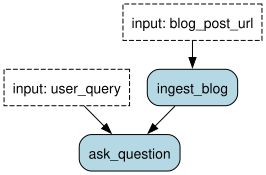

In [3]:
from burr.core import action, State, ApplicationBuilder

# `reads` and `writes` specify what data is read/written via the `State`.
@action(reads=[], writes=["blog_content"])
def ingest_blog(state: State, blog_post_url: str) -> State:
    """Download a blog post and parse it"""
    blog_content = ...
    return state.update(blog_content=blog_content)


@action(reads=["blog_content", "history"], writes=["history"])
def ask_question(state: State, user_query: str) -> State:
    """Reply to the user's query using the blog's content."""
    history = state["history"]
    blog_content = state["blog_content"]
    response = ...
    return state.append(history=response)


# the `ApplicationBuilder` receives the actions,
# specifies the transitions, and sets the starting action.
(
    ApplicationBuilder()
    .with_actions(ingest_blog, ask_question)
    .with_transitions(("ingest_blog", "ask_question"))
    .with_entrypoint("ingest_blog")
    .build()
)

In [4]:
import requests
import openai
from bs4 import BeautifulSoup
from burr.core import action, State, ApplicationBuilder


@action(reads=[], writes=["blog_content"])
def ingest_blog_v1(state: State, blog_post_url: str) -> State:
    """Download a blog post and parse it"""
    html_content = requests.get(blog_post_url).text
    soup = BeautifulSoup(html_content, "html.parser")
    blog_content = soup.get_text(separator=" ", strip=True)
    return state.update(blog_content=blog_content)


@action(reads=["blog_content"], writes=["llm_answer"])
def ask_question_v1(state: State, user_query: str) -> State:
    """Reply to the user's query using the blog's content."""
    blog_content = state["blog_content"]

    system_prompt = (
        "Answer the user's questions based on the provided blog post content. "
        "Answer in a concise and helpful manner, and tell the user "
        "if you don't know the answer or you're unsure.\n\n"
        f"BLOG CONTENT:\n{blog_content}"
    )

    client = openai.OpenAI()
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_query}
        ],
    )
    llm_answer = response.choices[0].message.content
    return state.update(llm_answer=llm_answer)

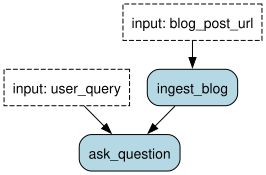

In [5]:
app_v1 = (
    ApplicationBuilder()
    .with_actions(ingest_blog=ingest_blog_v1, ask_question=ask_question_v1)
    .with_transitions(("ingest_blog", "ask_question"))
    .with_entrypoint("ingest_blog")
    .build()
)
app_v1

In [6]:
action_name, results, state = app_v1.run(
    halt_after=["ask_question"],
    inputs={
        "blog_post_url": "https://blog.dagworks.io/p/from-blog-to-bot-build-a-rag-app",
        "user_query": "What do you need to monitor in a RAG app?"
    }
)
print(state["llm_answer"])

In a RAG (Retrieval-Augmented Generation) app, you need to monitor several aspects, including:

1. **User Behavior Patterns**: Analyze frequent topics and difficult queries users might have.
2. **Application Performance**: Monitor performance metrics like guardrails, LLM randomness, and user ratings.
3. **System Performance**: Track latency, throughput, resource usage, and API calls.
4. **System Errors**: Detect bugs that may arise from code or interactions between code and data.

These metrics help ensure the application runs smoothly and meets user expectations.


Now that we have a working application, we can replace OpenAI with Anthropic.

In [7]:
import anthropic
import requests
from bs4 import BeautifulSoup
from burr.core import action, State, ApplicationBuilder


@action(reads=[], writes=["blog_content"])
def ingest_blog_v1(state: State, blog_post_url: str) -> State:
    """Download a blog post and parse it"""
    html_content = requests.get(blog_post_url).text
    soup = BeautifulSoup(html_content, "html.parser")
    blog_content = soup.get_text(separator=" ", strip=True)
    return state.update(blog_content=blog_content)


@action(reads=["blog_content"], writes=["llm_answer"])
def ask_question_v1(state: State, user_query: str) -> State:
    """Reply to the user's query using the blog's content."""
    blog_content = state["blog_content"]

    system_prompt = (
        "Answer the user's questions based on the provided blog post content. "
        "Answer in a concise and helpful manner, and tell the user "
        "if you don't know the answer or you're unsure.\n\n"
        f"BLOG CONTENT:\n{blog_content}"
    )

    client = anthropic.Anthropic()
    response = client.messages.create(
        model="claude-3-5-sonnet-20241022",
        max_tokens=1024,
        messages=[
            {"role": "user", "content": system_prompt},
            {"role": "user", "content": user_query}
        ],
    )
    llm_answer = response.content[0].text
    return state.update(llm_answer=llm_answer)

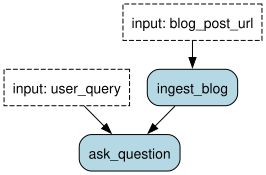

In [8]:
app_v1 = (
    ApplicationBuilder()
    .with_actions(ingest_blog=ingest_blog_v1, ask_question=ask_question_v1)
    .with_transitions(("ingest_blog", "ask_question"))
    .with_entrypoint("ingest_blog")
    .build()
)
app_v1

In [9]:
action_name, results, state = app_v1.run(
    halt_after=["ask_question"],
    inputs={
        "blog_post_url": "https://blog.dagworks.io/p/from-blog-to-bot-build-a-rag-app",
        "user_query": "What do you need to monitor in a RAG app?"
    }
)
print(state["llm_answer"])

According to the blog post, a RAG application should be monitored across four main areas:

1. User behavior patterns:
- Frequent topics
- Difficult queries

2. Application performance:
- Guardrails
- LLM randomness
- User ratings

3. System performance:
- Latency
- Throughput
- Resource usage
- API calls

4. System errors:
- Bugs from code
- Interaction between code and data

The post mentions that OpenTelemetry can be used for instrumentation to collect this telemetry data (metrics, logs, traces), and when using Burr, it can automatically track and store the OpenTelemetry data. The Burr UI provides visualization and monitoring capabilities for these metrics.


In [10]:
import re
import requests
import openai
import lancedb
from bs4 import BeautifulSoup
from burr.core import action, State, ApplicationBuilder
from lancedb.pydantic import LanceModel, Vector
from lancedb.embeddings import get_registry


embedding_model = get_registry().get("openai").create()

class TextDocument(LanceModel):
    """Simple data structure to hold a piece of text associated with a url."""
    url: str
    position: int
    text: str = embedding_model.SourceField()
    vector: Vector(dim=embedding_model.ndims()) = embedding_model.VectorField()


@action(reads=[], writes=[])
def ingest_blog_v2(state: State, blog_post_url: str) -> State:
    """Download a blog post and parse it"""
    # get the blog post as plain text
    html_content = requests.get(blog_post_url).text
    soup = BeautifulSoup(html_content, "html.parser")
    blog_content = soup.get_text(separator=" ", strip=True)
    # split the text by sentence
    SENTENCE_ENDINGS = r"[.!?]+"

    chunks = []
    for sentence in re.split(SENTENCE_ENDINGS, blog_content):
        sentence = sentence.strip()
        if sentence:
            chunks.append(sentence)

    # join sentences to create larger overlapping chunks
    window = 5
    stride = 3
    min_window_size = 2

    overlapping_chunks = []
    n_chunks = len(chunks)
    for start_i in range(0, n_chunks, stride):
        if (start_i + window <= n_chunks) or (n_chunks - start_i >= min_window_size):
            overlapping_chunks.append(" ".join(chunks[start_i : min(start_i + window, n_chunks)]))

    # embed and store the chunks using LanceDB
    con = lancedb.connect("./blogs")
    table = con.create_table("chunks", exist_ok=True, schema=TextDocument)
    table.add([
        {"text": c, "url": blog_post_url, "position": i}
        for i, c in enumerate(overlapping_chunks)
    ])

    return state


@action(reads=[], writes=["llm_answer"])
def ask_question_v2(state: State, user_query: str) -> State:
    """Reply to the user's query using the blog's content."""
    # retrieve the most relevant chunks
    chunks_table = lancedb.connect("./blogs").open_table("chunks")
    search_results = (
        chunks_table
        .search(user_query)
        .select(["text", "url", "position"])
        .limit(3)
        .to_list()
    )
    relevant_content = "\n".join([r["text"] for r in search_results])

    # prompt the LLM with the relevant content
    system_prompt = (
        "Answer the user's questions based on the provided blog post content. "
        f"BLOG CONTENT:\n{relevant_content}"
    )

    client = openai.OpenAI()
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_query}
        ],
    )
    llm_answer = response.choices[0].message.content
    return state.update(llm_answer=llm_answer)

/Users/brewc/PycharmProjects/BleakHouse/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


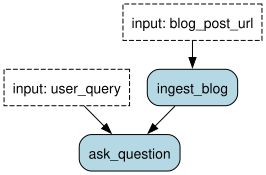

In [11]:
# "instrumenting" patches the libraries to log OpenTelemetry data
# from opentelemetry.instrumentation.lancedb import LanceInstrumentor
# from opentelemetry.instrumentation.openai import OpenAIInstrumentor

# OpenAIInstrumentor().instrument()
# LanceInstrumentor().instrument()

app_v2 = (
    ApplicationBuilder()
    .with_actions(ingest_blog=ingest_blog_v2, ask_question=ask_question_v2)
    .with_transitions(("ingest_blog", "ask_question"))
    .with_entrypoint("ingest_blog")
    # enable the tracker and enable OpenTelemetry via the argument
    .with_tracker(project="modular-rag", use_otel_tracing=True)
    .build()
)
app_v2

In [12]:
action_name, results, state = app_v2.run(
    halt_after=["ask_question"],
    inputs={
        "blog_post_url": "https://blog.dagworks.io/p/from-blog-to-bot-build-a-rag-app",
        "user_query": "What do you need to monitor in a RAG app?"
    }
)
print(state["llm_answer"])

In a RAG (Retrieval-Augmented Generation) application, you need to monitor the following aspects:

1. **User Behavior Patterns**: This includes analyzing frequent topics users are interested in and identifying difficult queries that users struggle with.

2. **Application Performance**: This encompasses monitoring guardrails, LLM randomness, and user ratings to assess how well the application is functioning.

3. **System Performance**: You should track latency, throughput, resource usage, and API calls to ensure the system is performing optimally.

4. **System Errors**: It's important to monitor for bugs that may arise from code issues or the interaction between code and data.

Enabling OpenTelemetry can help with collecting and exporting telemetry data related to these areas.


In [13]:
# execute cell to launch the UI
%burr_ui

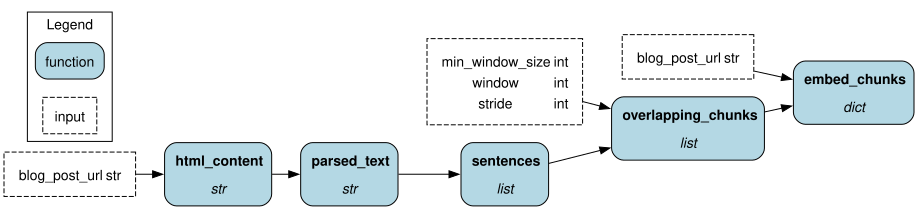

In [14]:
%%cell_to_module ingest_blog --display
import re
import requests
import lancedb
from bs4 import BeautifulSoup
from lancedb.pydantic import LanceModel, Vector
from lancedb.embeddings import get_registry


embedding_model = get_registry().get("openai").create()

class TextDocument(LanceModel):
    """Simple data structure to hold a piece of text associated with a url."""
    url: str
    position: int
    text: str = embedding_model.SourceField()
    vector: Vector(dim=embedding_model.ndims()) = embedding_model.VectorField()


def html_content(blog_post_url: str) -> str:
    return requests.get(blog_post_url).text


def parsed_text(html_content: str) -> str:
    soup = BeautifulSoup(html_content, "html.parser")
    return soup.get_text(separator=" ", strip=True)


def sentences(parsed_text: str) -> list[str]:
    return [
        sentence.strip()
        for sentence in re.split(r"[.!?]+", parsed_text)
        if sentence.strip()
    ]


def overlapping_chunks(
    sentences: list[str],
    window: int = 5,
    stride: int = 3,
    min_window_size: int = 2
) -> list[str]:
    overlapping_chunks = []
    n_chunks = len(sentences)
    for start_i in range(0, n_chunks, stride):
        if (start_i + window <= n_chunks) or (n_chunks - start_i >= min_window_size):
            overlapping_chunks.append(" ".join(sentences[start_i : min(start_i + window, n_chunks)]))
    return overlapping_chunks


def embed_chunks(overlapping_chunks: list[str], blog_post_url: str) -> dict:
    # embed and store the chunks using LanceDB
    con = lancedb.connect("./blogs")
    table = con.create_table("chunks", exist_ok=True, schema=TextDocument)
    table.add([
        {"text": c, "url": blog_post_url, "position": i}
        for i, c in enumerate(overlapping_chunks)
    ])
    return {"n_chunks_embedded": len(overlapping_chunks)}

In [15]:
from hamilton.driver import Builder

ingest_dr = Builder().with_modules(ingest_blog).with_cache().build()

In [16]:
results = ingest_dr.execute(
    ["sentences"],
    inputs={"blog_post_url": "https://blog.dagworks.io/p/building-a-better-feature-platform"},
)
print(results["sentences"][17])

At a high level, the list included capabilities like: Connects to our existing data sources (Snowflake, S3, Postgres, etc


In [17]:
print(results["sentences"][10])

Subscribe for free to receive new posts on data, AI, & ML Subscribe We knew we could increase efficiency for our data scientists, minimize train-serve skew, and unlock new use cases that hadn’t been explored yet


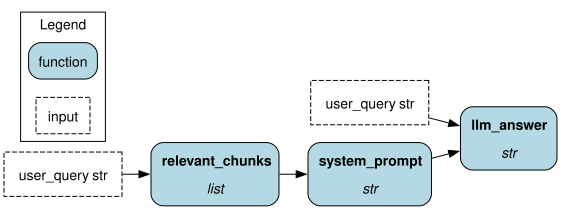

In [18]:
%%cell_to_module ask_question --display
import openai
import lancedb

def relevant_chunks(user_query: str) -> list[dict]:
    chunks_table = lancedb.connect("./blogs").open_table("chunks")
    search_results = (
        chunks_table
        .search(user_query)
        .select(["text", "url", "position"])
        .limit(3)
        .to_list()
    )
    return search_results


def system_prompt(relevant_chunks: list[dict]) -> str:
    relevant_content = "\n".join([c["text"] for c in relevant_chunks])
    return (
        "Answer the user's questions based on the provided blog post content. "
        "Answer in a concise and helpful manner, and tell the user "
        "if you don't know the answer or you're unsure.\n\n"
        f"BLOG CONTENT:\n{relevant_content}"
    )

def llm_answer(system_prompt: str, user_query: str) -> str:
    client = openai.OpenAI()
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_query}
        ],
    )
    return response.choices[0].message.content

In [19]:
from hamilton.driver import Builder
from hamilton.plugins.h_opentelemetry import OpenTelemetryTracer
from burr.core import action, State, ApplicationBuilder

# these imports will only work if you executed the cells that
# defines them using the `%%cell_to_module` magic
import ingest_blog
import ask_question


@action(reads=[], writes=[])
def ingest_blog_v3(state: State, blog_post_url: str) -> State:
    """Download a blog post and parse it"""
    dr = (
        Builder()
        .with_modules(ingest_blog)
        .with_adapters(OpenTelemetryTracer())
        .build()
    )
    dr.execute(["embed_chunks"], inputs={"blog_post_url": blog_post_url})
    return state


@action(reads=[], writes=["llm_answer"])
def ask_question_v3(state: State, user_query: str) -> State:
    """Reply to the user's query using the blog's content."""
    dr = (
        Builder()
        .with_modules(ask_question)
        .with_adapters(OpenTelemetryTracer())
        .build()
    )
    results = dr.execute(["llm_answer"], inputs={"user_query": user_query})
    return state.update(llm_answer=results["llm_answer"])

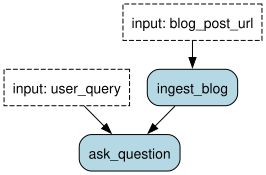

In [20]:
app_v3 = (
    ApplicationBuilder()
    .with_actions(ingest_blog=ingest_blog_v3, ask_question=ask_question_v3)
    .with_transitions(("ingest_blog", "ask_question"))
    .with_entrypoint("ingest_blog")
    .with_tracker(project="modular-rag", use_otel_tracing=True)
    .build()
)
app_v3

In [21]:
action_name, results, state = app_v3.run(
    halt_after=["ask_question"],
    inputs={
        "blog_post_url": "https://blog.dagworks.io/p/from-blog-to-bot-build-a-rag-app",
        "user_query": "What do you need to monitor in a RAG app?"
    }
)
print(state["llm_answer"])

In a RAG (Retrieval-Augmented Generation) application, you need to monitor the following:

1. **User behavior patterns** - Analyzing frequent topics and difficult queries.
2. **Application performance** - Monitoring guardrails, LLM randomness, and user ratings.
3. **System performance** - Tracking latency, throughput, resource usage, and API calls.
4. **System errors** - Identifying bugs from the code or interactions between code and data. 

Additionally, enabling OpenTelemetry can help in instrumenting your code to collect and report telemetry data.


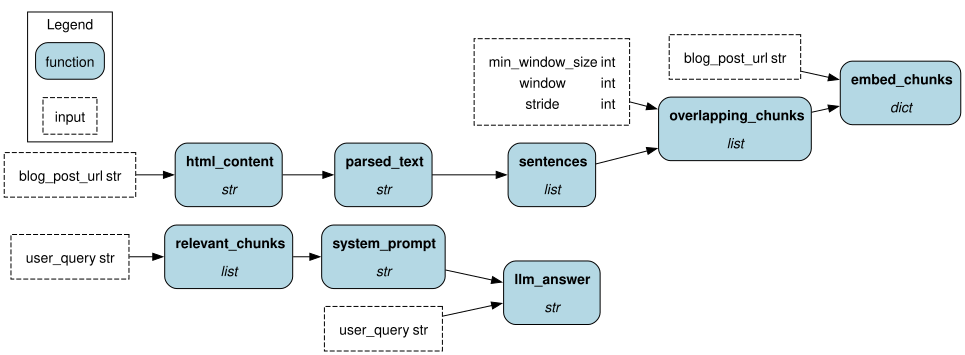

In [22]:
dr = Builder().with_modules(ingest_blog, ask_question).with_adapters(OpenTelemetryTracer()).build()
dr

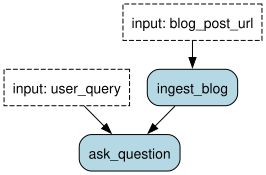

In [23]:
from hamilton.driver import Driver, Builder
from burr.core import action, State, ApplicationBuilder


@action(reads=[], writes=[])
def ingest_blog_v3_2(state: State, blog_post_url: str, dr: Driver) -> State:
    """Download a blog post and parse it"""
    dr.execute(["embed_chunks"], inputs={"blog_post_url": blog_post_url})
    return state


@action(reads=[], writes=["llm_answer"])
def ask_question_v3_2(state: State, user_query: str, dr: Driver) -> State:
    """Reply to the user's query using the blog's content."""
    results = dr.execute(["llm_answer"], inputs={"user_query": user_query})
    return state.update(llm_answer=results["llm_answer"])


app_v3_2 = (
    ApplicationBuilder()
    .with_actions(
        ingest_blog=ingest_blog_v3_2.bind(dr=dr),
        ask_question=ask_question_v3_2.bind(dr=dr)
    )
    .with_transitions(("ingest_blog", "ask_question"))
    .with_entrypoint("ingest_blog")
    .build()
)
app_v3_2

In [24]:
action_name, results, state = app_v3_2.run(
    halt_after=["ask_question"],
    inputs={
        "blog_post_url": "https://blog.dagworks.io/p/from-blog-to-bot-build-a-rag-app",
        "user_query": "What do you need to monitor in a RAG app?"
    }
)

In [27]:
state

{'__SEQUENCE_ID': 1, '__PRIOR_STEP': 'ask_question', 'llm_answer': 'In a RAG (Retrieval-Augmented Generation) app, you need to monitor the following:\n\n1. **User Behavior Patterns**: Frequent topics and difficult queries.\n2. **Application Performance**: Guardrails, LLM randomness, and user ratings.\n3. **System Performance**: Latency, throughput, resource usage, and API calls.\n4. **System Errors**: Bugs from code or the interaction between code and data.\n\nThis helps ensure the application is functioning effectively and provides insights for improvements.'}